# 📊 Análisis Exploratorio de Datos (EDA)
## Telco Customer Churn

---

## Objetivo del análisis

Este notebook explora los datos de clientes de una compañía de telecomunicaciones para entender qué factores están asociados al churn (abandono del servicio).

Buscamos:

- Ver la calidad y estructura del dataset
- Limpiar variables numéricas importantes
- Comparar el churn según tipo de contrato, método de pago y cargos mensuales
- Preparar un dataset limpio para modelar

---

## Índice

1. Carga del dataset y revisión inicial
2. Limpieza de `TotalCharges`
3. Contrato y churn
4. Gasto mensual y churn
5. Servicios y método de pago
6. Análisis de `MonthlyCharges`
7. Conclusiones

---

## Descripción del dataset

El conjunto de datos contiene información de clientes, entre otras:

- Datos demográficos (género, edad)
- Servicios contratados (internet, TV, soporte, seguridad, streaming)
- Tipo de contrato y método de pago
- Cargos mensuales y totales
- Variable objetivo: **Churn**

---

## Tipo de problema

Esta es una tarea de:

➡️ **Clasificación binaria**

Queremos predecir si un cliente permanecerá en el servicio (`No`) o lo abandonará (`Yes`).

## Carga del dataset y revisión inicial

En esta sección se importan las librerías necesarias, se carga el dataset y se realiza una exploración inicial del contenido.

Se revisan:

- las primeras filas del dataset
- el tamaño del dataset (filas y columnas)
- los tipos de datos de cada variable
- la presencia de valores faltantes o inconsistencias

Este paso es esencial para validar la calidad de los datos antes de continuar con el análisis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

display(df.head())
print("Shape:", df.shape)
print(df.dtypes)



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Shape: (7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


## Análisis de variables numéricas y limpieza de datos

En esta sección se exploran variables numéricas clave y se corrige el tipo de datos de `TotalCharges`, que originalmente se almacenaba como texto.

Las tareas realizadas son:

- Revisión de estadísticas descriptivas de `MonthlyCharges`.
- Conversión de `TotalCharges` a numérico.
- Identificación y tratamiento de valores nulos.
- Validación del dataset después de la limpieza.

Este proceso garantiza que los datos estén listos para análisis posteriores y modelado.

In [ ]:
display(df["MonthlyCharges"].describe())

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" ",np.nan), errors="coerce")


In [4]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [ ]:
# Filas con TotalCharges faltante antes de imputar
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [6]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [7]:
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn


## Relación entre contrato y churn

En este bloque se analiza cómo el tipo de contrato está relacionado con la probabilidad de abandono del servicio.

Este análisis ayuda a identificar si los clientes con contrato mensual, anual o de dos años se comportan de forma distinta respecto al churn.

In [ ]:
print(df["Contract"].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

## Contrato y churn - resultados

- El tipo de contrato más frecuente es **Month-to-month**, lo cual sugiere una base de clientes con menor fidelización.

- Existe una relación clara entre contrato y churn:
  - **Month-to-month** presenta la mayor tasa de abandono.
  - Contratos de **un año** tienen menos churn.
  - Contratos de **dos años** presentan la tasa más baja.

- Se identificaron **415 clientes** con un paquete completo de servicios, un segmento importante para análisis adicional.

- Los clientes que se van (`Churn = Yes`) pagan en promedio ~**74 USD** al mes, frente a ~**61 USD** para los que permanecen.

Estos resultados muestran que el tipo de contrato y el nivel de gasto mensual son variables clave en el churn.

In [ ]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


## Análisis del gasto mensual y churn

Se estudia la relación entre los cargos mensuales (`MonthlyCharges`) y la probabilidad de churn, con el objetivo de determinar si el nivel de gasto está asociado al abandono del servicio.

También se identifica un subconjunto de clientes con el paquete completo de servicios para analizar si este segmento se comporta de forma distinta.

In [ ]:
df_full = df[
    (df["InternetService"] != "No") &
    (df["StreamingTV"] == "Yes") &
    (df["StreamingMovies"] == "Yes") &
    (df["OnlineSecurity"] == "Yes") &
    (df["TechSupport"] == "Yes") &
    (df["DeviceProtection"] == "Yes")
]

print("Clientes con paquete completo:", len(df_full))

415

## Gasto mensual y churn - resultados

- El subconjunto de clientes con paquete completo es de **415 clientes**.

- El promedio de cargos mensuales es:
  - ~**61 USD** para clientes que permanecen.
  - ~**74 USD** para clientes que abandonan.

- Esto sugiere que los clientes con mayores cargos mensuales tienen una mayor probabilidad de churn.

- En términos de negocio, los planes más costosos pueden requerir acciones específicas de retención.

In [ ]:
print(df.groupby("Churn")["MonthlyCharges"].mean())

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

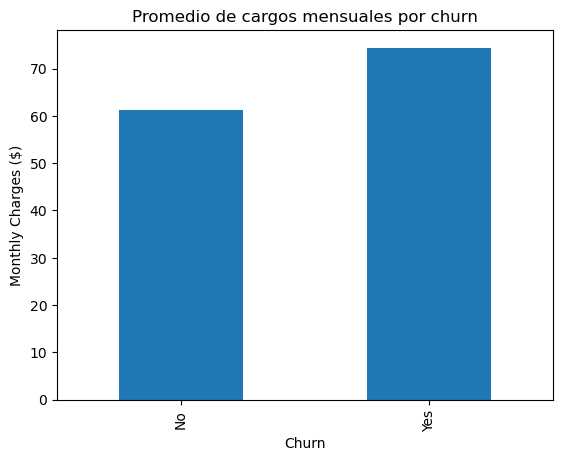

In [ ]:
print(df.groupby("InternetService")["MonthlyCharges"].mean())
avg_charges = df.groupby("Churn")["MonthlyCharges"].mean()

avg_charges.plot(kind="bar")
plt.title("Promedio de cargos mensuales por churn")
plt.ylabel("Monthly Charges ($)")
plt.xlabel("Churn")
plt.tight_layout()
plt.show()

## Análisis de servicios y método de pago

En esta sección se analiza la distribución de los servicios de internet y los métodos de pago utilizados por los clientes.

Adicionalmente, se estudia la relación entre el método de pago y el churn, con el objetivo de identificar si ciertos métodos están asociados a una mayor tasa de cancelación.

También se analiza el tiempo promedio de permanencia (`tenure`) de los clientes en la compañía.

In [ ]:
print(df["InternetService"].value_counts())

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

## Servicio y método de pago - resultados

- El servicio de internet más utilizado es **Fiber optic**, seguido de **DSL**.

- El método de pago más frecuente es **Electronic check**, seguido por **Mailed check** y métodos automáticos.

- El churn es mayor en **Electronic check** y menor en los métodos automáticos.

- El tiempo promedio de permanencia (`tenure`) es de aproximadamente **32 meses**.

Estos hallazgos indican que las formas de pago y el servicio de internet son factores relevantes para la retención.

In [ ]:
print(df["PaymentMethod"].value_counts())

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

## Análisis de churn por método de pago

En esta sección se examina cómo varía el churn según el método de pago de cada cliente.

Se calculan los porcentajes de clientes que permanecen y que abandonan el servicio por método de pago, y se visualizan para facilitar la interpretación.

También se incorpora el análisis del tiempo promedio de permanencia (`tenure`) para complementar la comprensión del comportamiento.

In [47]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [ ]:
print("Promedio de tenure:", df["tenure"].mean())

np.float64(32.37114865824223)

## Churn por método de pago - resultados

- **Electronic check** presenta la tasa de churn más alta (~45%).

- Los métodos automáticos (**Bank transfer (automatic)** y **Credit card (automatic)**) tienen tasas de churn más bajas (~15%-17%).

- **Mailed check** tiene una tasa intermedia (~19%).

- El tiempo promedio de permanencia es de ~**32 meses**.

Esto refuerza la idea de que los métodos de pago automáticos están asociados a mejor retención.

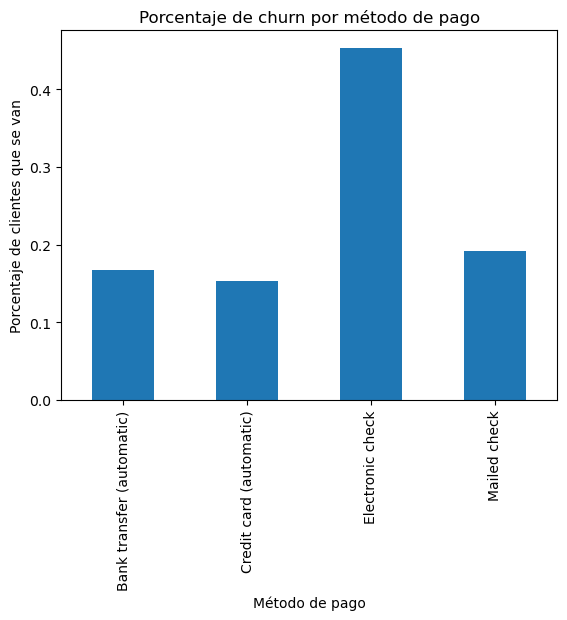

In [49]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")["Yes"].plot(kind="bar")

plt.title("Porcentaje de churn por método de pago")
plt.ylabel("Porcentaje de clientes que se van")
plt.xlabel("Método de pago")

plt.show()

## Análisis univariado: MonthlyCharges

En esta sección se analiza la variable `MonthlyCharges` de forma individual para comprender su distribución y su dispersión.

Se utilizan herramientas estadísticas y visuales como:

- Varianza: para medir la dispersión
- Histograma: para observar la forma de la distribución
- Boxplot: para identificar la mediana, cuartiles y posibles outliers

Este análisis ayuda a entender cómo se distribuyen los cargos mensuales entre los clientes y si existen rangos de precio relevantes.

In [ ]:
print("Varianza de MonthlyCharges:", df["MonthlyCharges"].var())

np.float64(905.4109343405098)

## MonthlyCharges: interpretación

- La varianza de los cargos mensuales es alta (~905), lo que indica una amplia dispersión en los valores.

- El histograma muestra concentraciones en rangos específicos, no una distribución uniforme.

- Existe una agrupación importante entre **70 y 100 USD**, lo que puede corresponder a planes más completos.

- El boxplot indica que la mediana está alrededor de **70 USD** y que la dispersión es amplia, sin outliers extremos claros.

Estos resultados sugieren una oferta de planes variada y clientes con distintos niveles de gasto.

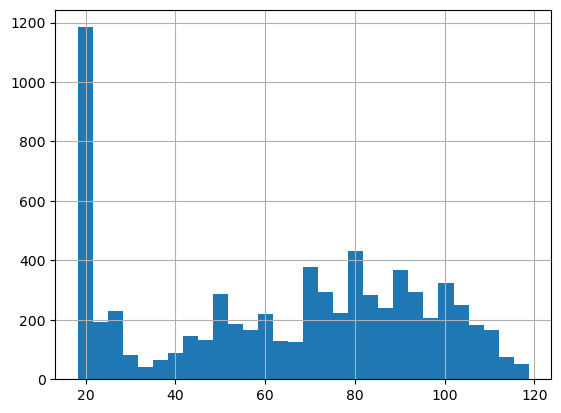

In [ ]:
df["MonthlyCharges"].hist(bins=30)
plt.show()

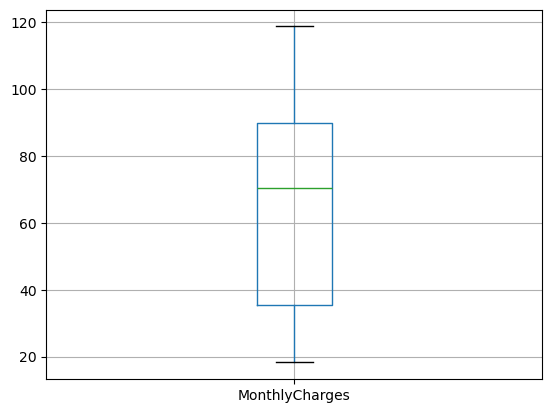

In [52]:
df.boxplot(column="MonthlyCharges")
plt.show()

In [ ]:
print("Desviación estándar de MonthlyCharges:", df["MonthlyCharges"].std())

np.float64(30.090047097678493)

## Análisis bivariado: MonthlyCharges vs Churn

En este punto se compara la distribución de los cargos mensuales entre los clientes que se van y los que se quedan, para evaluar si el gasto mensual tiene un impacto en la probabilidad de churn.

<Axes: title={'center': 'MonthlyCharges'}, xlabel='Churn'>

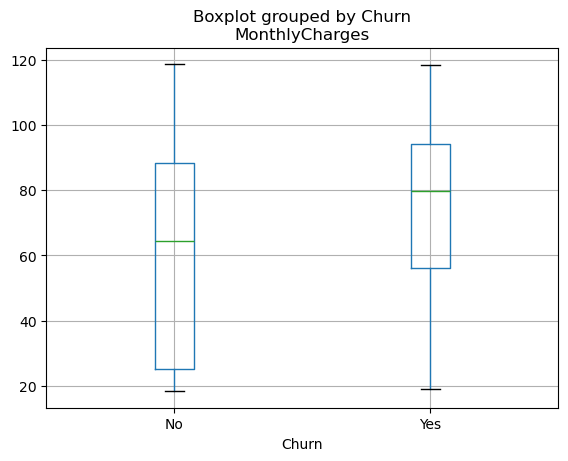

In [55]:
df.boxplot(column="MonthlyCharges", by="Churn")

In [60]:
df.to_csv("telco_clean.csv", index=False)

## Conclusiones del análisis exploratorio (EDA)

A partir del análisis realizado, se identifican los siguientes hallazgos principales:

- Los clientes con cargos mensuales más altos tienen una mayor probabilidad de churn.
- Los contratos **Month-to-month** son los más frecuentes y muestran la tasa de churn más alta.
- Los métodos de pago manuales, especialmente **Electronic check**, tienen una asociación clara con mayores tasas de abandono.
- Los clientes que permanecen tienden a pagar menos en promedio (~61 USD), mientras que los que se van pagan más (~74 USD).
- El dataset muestra alta variabilidad en los cargos mensuales, lo cual sugiere una oferta de planes diversa.

Recomendaciones de negocio:

- Incentivar contratos de mayor duración.
- Promover métodos de pago automáticos.
- Analizar la relación entre precio y percepción de valor del servicio.

Estos hallazgos proporcionan una base sólida para avanzar hacia la construcción de modelos de Machine Learning para predecir churn.